# 龟龟选股器 (Turtle Screener)

## 两层架构批量筛选器

从全A股 ~5000 只中，用策略所有可量化指标快速过滤候选标的。

### 流水线总览

```
全A股 ~5000只
    │
    ▼
┌─────────────────────────────────┐
│  Tier 1: 批量粗筛 (~5秒)        │
│  2个API调用，7个硬性过滤条件      │
│  ┌───────────┐ ┌──────────────┐ │
│  │ 主通道     │ │ 观察通道      │ │
│  │ PE>0       │ │ PE=NaN(亏损股)│ │
│  │ Top 150    │ │ Top 50       │ │
│  └───────────┘ └──────────────┘ │
└─────────────────────────────────┘
    │  ~200只
    ▼
┌─────────────────────────────────┐
│  Tier 2: 逐股深度分析 (~5秒/股)  │
│  财务质量 → 因子2/4 → 底价       │
│  ┌──────┐ ┌──────┐ ┌─────────┐ │
│  │硬性否决│ │质量门槛│ │因子+底价 │ │
│  │质押/审计│ │ROE/毛利│ │R/EV/FCF │ │
│  └──────┘ └──────┘ └─────────┘ │
└─────────────────────────────────┘
    │
    ▼
  综合评分排名 → 导出结果
```

### 指标体系

| 层级 | 指标 | 作用 |
|------|------|------|
| Tier 1 | ST状态、上市年限、市值、换手率、PB、PE、股息率 | 快速排除不合格标的 |
| Tier 2 硬性否决 | 质押比例、审计意见 | 一票否决高风险股 |
| Tier 2 质量门槛 | ROE、毛利率、资产负债率 | 确保基本面质量 |
| Tier 2 因子 | 穿透回报率R、EV/EBITDA、FCF收益率、底价溢价率 | 估值与安全边际 |

## Step 1: 环境初始化与参数配置

下方代码完成两件事：**加载依赖** 和 **设定筛选参数**。

所有参数均可自定义修改。默认值及其含义：

### Tier 1 硬性过滤

| 参数 | 默认值 | 含义 |
|------|--------|------|
| `min_listing_years` | 3 | 排除次新股，确保至少3年完整年报数据可供分析 |
| `min_market_cap_yi` | 5.0亿 | 最低市值门槛，确保基本流动性，排除壳公司 |
| `min_turnover_pct` | 0.1% | 最低换手率，排除长期零成交的僵尸股 |
| `max_pb` | 10.0 | PB上限，排除资产泡沫或轻资产高溢价股 |
| `max_pe` | 50.0 | PE上限，排除过度乐观定价的成长股 |
| `obs_channel_limit` | 50 | 观察通道（PE=NaN亏损股）最多保留数量 |

### Tier 1 排序权重

| 参数 | 默认值 | 含义 |
|------|--------|------|
| `dv_weight` | 0.4 | 股息率权重（龟龟策略以收息为核心） |
| `pe_weight` | 0.3 | 1/PE 权重（低PE=更快回本） |
| `pb_weight` | 0.3 | 1/PB 权重（低PB=资产安全垫） |
| `tier2_main_limit` | 150 | 主通道进入Tier 2的最大数量 |

### Tier 2 质量门槛

| 参数 | 默认值 | 含义 |
|------|--------|------|
| `max_pledge_pct` | 70.0% | 质押比例上限，超过则一票否决 |
| `min_roe` | 8.0% | ROE最低门槛，确保资本回报效率（高于一般理财收益率）|
| `min_gross_margin` | 15.0% | 毛利率下限，确保具备一定护城河和定价权 |
| `max_debt_ratio` | 70.0% | 资产负债率上限，控制财务杠杆风险 |

### Tier 2 综合评分权重

| 参数 | 默认值 | 含义 |
|------|--------|------|
| `weight_penetration_r` | 0.25 | 穿透回报率R（策略核心，权重最高） |
| `weight_roe` | 0.20 | ROE 资本回报效率 |
| `weight_fcf_yield` | 0.20 | FCF收益率 现金创造能力 |
| `weight_floor_premium` | 0.20 | 底价溢价率（越低=安全边际越大） |
| `weight_ev_ebitda` | 0.15 | EV/EBITDA（越低=越便宜） |

> **设计理念**：参数取值偏保守，宁可错过（假阴性）也不误选（假阳性）。
> 对于银行等高杠杆行业，`max_debt_ratio=70%` 会自动放宽。
> 评分权重之和必须等于 1.0。

## Core Engine

下方代码定义了选股器的完整引擎，包含三个核心组件：

| 组件 | 作用 |
|------|------|
| `ScreenerConfig` | 所有可调参数的数据类（阈值、权重、缓存设置） |
| `ScreenerCache` | Parquet 磁盘缓存，按 TTL 自动失效 |
| `TushareScreener` | 筛选器主类：Tier 1 批量粗筛 + Tier 2 逐股深度分析 |

> 通常无需修改此单元格。如需调整筛选逻辑（如修改过滤条件、评分公式），可直接编辑对应方法。

In [1]:
# Engine: ScreenerConfig + ScreenerCache + TushareScreener (inlined from scripts/)
# ---------------------------------------------------------------
# This cell defines the full screening engine so the notebook is
# self-contained — no imports from scripts/ are needed.
# ---------------------------------------------------------------

from __future__ import annotations

import hashlib
import os
import time
from dataclasses import dataclass, field, asdict
from datetime import datetime, timedelta
from typing import Any

import pandas as pd


# ============================================================
# Project root detection (robust across cwd variations)
# ============================================================

def _find_project_root() -> str:
    """Walk up from cwd to find project root (contains .git/)."""
    d = os.path.abspath('')
    for _ in range(5):
        if os.path.isdir(os.path.join(d, '.git')):
            return d
        d = os.path.dirname(d)
    return os.path.abspath('')

_PROJECT_ROOT = _find_project_root()


# ============================================================
# .env loader & token helper (from scripts/config.py)
# ============================================================

def _load_env_file() -> None:
    """Load .env file from project root if it exists."""
    env_path = os.path.join(_PROJECT_ROOT, '.env')
    if not os.path.isfile(env_path):
        return
    with open(env_path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            if '=' in line:
                key, _, value = line.partition('=')
                key = key.strip()
                value = value.strip().strip("'\"")
                if key and key not in os.environ:
                    os.environ[key] = value


def _get_token() -> str:
    """Get Tushare Pro API token from environment or .env file."""
    _load_env_file()
    token = os.environ.get('TUSHARE_TOKEN', '')
    if not token:
        raise RuntimeError(
            'TUSHARE_TOKEN is not set.\n'
            'Option 1: Copy .env.sample to .env and fill in your token\n'
            'Option 2: export TUSHARE_TOKEN="your_token_here"\n'
            'Get a token at: https://tushare.pro/register'
        )
    return token


# ============================================================
# ScreenerConfig (from scripts/screener_config.py)
# ============================================================

@dataclass
class ScreenerConfig:
    """All tunable parameters for the screener pipeline."""

    # --- Tier 1: Hard filters ---
    min_listing_years: int = 3
    min_market_cap_yi: float = 5.0
    min_turnover_pct: float = 0.1
    max_pb: float = 10.0
    max_pe: float = 50.0
    include_bank: bool = False

    # --- Tier 1: Dual-channel PE ---
    obs_channel_limit: int = 50

    # --- Tier 1: Ranking & cutoff ---
    tier2_main_limit: int = 150
    dv_weight: float = 0.4
    pe_weight: float = 0.3
    pb_weight: float = 0.3

    # --- Tier 2: Hard vetoes ---
    max_pledge_pct: float = 70.0

    # --- Tier 2: Financial quality ---
    min_roe: float = 8.0
    min_gross_margin: float = 15.0
    max_debt_ratio: float = 70.0

    # --- Scoring weights ---
    weight_roe: float = 0.20
    weight_fcf_yield: float = 0.20
    weight_penetration_r: float = 0.25
    weight_ev_ebitda: float = 0.15
    weight_floor_premium: float = 0.20

    # --- Cache ---
    cache_dir: str = ""
    cache_stock_basic_ttl_days: int = 7
    cache_daily_basic_ttl_days: int = 0
    cache_rf_ttl_days: int = 1
    cache_tier2_ttl_hours: int = 24
    cache_tier2_financial_ttl_hours: int = 168
    cache_tier2_market_ttl_hours: int = 24
    cache_tier2_global_ttl_hours: int = 24

    def __post_init__(self):
        if not self.cache_dir:
            self.cache_dir = os.path.join(_PROJECT_ROOT, "output", ".screener_cache")

    @property
    def tier2_max_stocks(self) -> int:
        return self.tier2_main_limit + self.obs_channel_limit

    @property
    def scoring_weights(self) -> dict[str, float]:
        return {
            "roe": self.weight_roe,
            "fcf_yield": self.weight_fcf_yield,
            "penetration_r": self.weight_penetration_r,
            "ev_ebitda": self.weight_ev_ebitda,
            "floor_premium": self.weight_floor_premium,
        }

    def validate(self) -> list[str]:
        errors = []
        w_sum = (self.weight_roe + self.weight_fcf_yield +
                 self.weight_penetration_r + self.weight_ev_ebitda +
                 self.weight_floor_premium)
        if abs(w_sum - 1.0) > 0.01:
            errors.append(f"Scoring weights must sum to 1.0, got {w_sum:.3f}")
        if self.min_listing_years < 0:
            errors.append("min_listing_years must be >= 0")
        if self.min_market_cap_yi < 0:
            errors.append("min_market_cap_yi must be >= 0")
        if self.tier2_main_limit < 1:
            errors.append("tier2_main_limit must be >= 1")
        if self.obs_channel_limit < 0:
            errors.append("obs_channel_limit must be >= 0")
        return errors

    def to_dict(self) -> dict[str, Any]:
        return asdict(self)

    @classmethod
    def from_dict(cls, d: dict[str, Any]) -> "ScreenerConfig":
        valid_keys = {f.name for f in cls.__dataclass_fields__.values()}
        filtered = {k: v for k, v in d.items() if k in valid_keys}
        return cls(**filtered)


# ============================================================
# Tier 2 field supersets (from screener_core.py)
# ============================================================

_TIER2_FIELDS = {
    "income": "ts_code,end_date,n_income_attr_p,operate_profit,finance_exp,non_oper_income,oth_income,asset_disp_income",
    "balancesheet": ("ts_code,end_date,money_cap,trad_asset,st_borr,lt_borr,"
                     "bond_payable,non_cur_liab_due_1y,goodwill,total_assets,"
                     "total_hldr_eqy_exc_min_int"),
    "cashflow": ("ts_code,end_date,n_cashflow_act,c_pay_acq_const_fiolta,"
                 "depr_fa_coga_dpba,amort_intang_assets,lt_amort_deferred_exp"),
    "dividend": "ts_code,end_date,cash_div_tax,base_share",
    "fina_indicator": ("ts_code,end_date,roe_waa,grossprofit_margin,"
                       "debt_to_assets,profit_dedt,"
                       "ebitda,fcff,netdebt,interestdebt"),
    "fina_audit": "ts_code,end_date,audit_result",
    "pledge_stat": "ts_code,end_date,pledge_count,pledge_ratio",
    "weekly": "ts_code,trade_date,close",
    "yc_cb": "trade_date,yield",
}

_TIER2_TTL_CATEGORY = {
    "income": "financial",
    "balancesheet": "financial",
    "cashflow": "financial",
    "dividend": "financial",
    "fina_indicator": "financial",
    "fina_audit": "financial",
    "pledge_stat": "financial",
    "weekly": "market",
    "yc_cb": "global",
}


# ============================================================
# ScreenerCache (from screener_core.py)
# ============================================================

class ScreenerCache:
    """Parquet-based disk cache with TTL."""

    def __init__(self, cache_dir: str):
        self.cache_dir = cache_dir
        os.makedirs(cache_dir, exist_ok=True)

    def _path(self, key: str) -> str:
        safe_key = hashlib.md5(key.encode()).hexdigest()
        return os.path.join(self.cache_dir, f"{safe_key}.parquet")

    def _meta_path(self, key: str) -> str:
        safe_key = hashlib.md5(key.encode()).hexdigest()
        return os.path.join(self.cache_dir, f"{safe_key}.meta")

    def get(self, key: str, ttl_seconds: int) -> pd.DataFrame | None:
        path = self._path(key)
        meta_path = self._meta_path(key)
        if not os.path.exists(path) or not os.path.exists(meta_path):
            return None
        try:
            with open(meta_path) as f:
                ts = float(f.read().strip().split("\n")[0])
            if time.time() - ts > ttl_seconds:
                return None
            return pd.read_parquet(path)
        except Exception:
            return None

    def put(self, key: str, df: pd.DataFrame) -> None:
        path = self._path(key)
        meta_path = self._meta_path(key)
        try:
            df.to_parquet(path, index=False)
            with open(meta_path, "w") as f:
                f.write(f"{time.time()}\n{key}")
        except Exception:
            pass

    def invalidate(self, key: str) -> None:
        for p in [self._path(key), self._meta_path(key)]:
            if os.path.exists(p):
                os.remove(p)

    def invalidate_prefix(self, prefix: str) -> None:
        if not os.path.isdir(self.cache_dir):
            return
        for f in os.listdir(self.cache_dir):
            if not f.endswith(".meta"):
                continue
            fp = os.path.join(self.cache_dir, f)
            try:
                with open(fp) as fh:
                    lines = fh.read().strip().split("\n")
                original_key = lines[1] if len(lines) > 1 else ""
                if original_key.startswith(prefix):
                    os.remove(fp)
                    parquet = fp.replace(".meta", ".parquet")
                    if os.path.exists(parquet):
                        os.remove(parquet)
            except Exception:
                pass

    def clear(self) -> None:
        if os.path.isdir(self.cache_dir):
            for f in os.listdir(self.cache_dir):
                fp = os.path.join(self.cache_dir, f)
                if os.path.isfile(fp):
                    os.remove(fp)


# ============================================================
# TushareScreener (from screener_core.py, everything except CLI main())
# ============================================================

class TushareScreener:
    """Main screener class: Tier 1 bulk screening + Tier 2 deep analysis."""

    def __init__(self, token: str | None = None, config: ScreenerConfig | None = None):
        self.config = config or ScreenerConfig()
        self._token = token or _get_token()
        self._pro = None
        self.cache = ScreenerCache(self.config.cache_dir)
        self._rf_cache: float | None = None
        self._stock_data_cache: dict[str, pd.DataFrame] = {}

    def _get_pro(self):
        if self._pro is None:
            import tushare as ts
            ts.set_token(self._token)
            self._pro = ts.pro_api(timeout=30)
        return self._pro

    def _safe_call(self, api_name: str, **kwargs) -> pd.DataFrame:
        pro = self._get_pro()
        last_err = None
        for attempt in range(1, 4):
            try:
                time.sleep(0.5)
                api_func = getattr(pro, api_name)
                return api_func(**kwargs)
            except Exception as e:
                last_err = e
                if attempt < 3:
                    import tushare as ts
                    self._pro = ts.pro_api(timeout=30)
                    time.sleep(1.0 * attempt)
        raise RuntimeError(f"Tushare API '{api_name}' failed after 3 retries: {last_err}")

    def _cached_call(self, api_name: str, ts_code: str | None = None,
                     **kwargs) -> pd.DataFrame:
        if ts_code is not None:
            cache_key = f"tier2_{ts_code}_{api_name}"
        else:
            cache_key = f"global_{api_name}"

        if cache_key in self._stock_data_cache:
            return self._stock_data_cache[cache_key]

        category = _TIER2_TTL_CATEGORY.get(api_name, "financial")
        cfg = self.config
        if category == "financial":
            ttl_seconds = cfg.cache_tier2_financial_ttl_hours * 3600
        elif category == "market":
            ttl_seconds = cfg.cache_tier2_market_ttl_hours * 3600
        else:
            ttl_seconds = cfg.cache_tier2_global_ttl_hours * 3600

        disk_df = self.cache.get(cache_key, ttl_seconds)
        if disk_df is not None:
            self._stock_data_cache[cache_key] = disk_df
            return disk_df

        call_kwargs = dict(kwargs)
        if api_name in _TIER2_FIELDS:
            call_kwargs["fields"] = _TIER2_FIELDS[api_name]
        if ts_code is not None:
            call_kwargs["ts_code"] = ts_code

        df = self._safe_call(api_name, **call_kwargs)

        if not df.empty:
            self._stock_data_cache[cache_key] = df
            self.cache.put(cache_key, df)

        return df

    def _clear_stock_cache(self, ts_code: str) -> None:
        prefix = f"tier2_{ts_code}_"
        keys_to_remove = [k for k in self._stock_data_cache if k.startswith(prefix)]
        for k in keys_to_remove:
            del self._stock_data_cache[k]

    # ---- Tier 1: Bulk data ----

    def _get_latest_trade_date(self) -> str:
        """Get the latest trading date with fully-populated daily_basic data.

        Before 19:00, today's data may not be ready (dv_ttm etc. are None),
        so we use yesterday as the end_date to get the previous trade date.
        """
        now = datetime.now()
        if now.hour < 23:
            end = (now - timedelta(days=1)).strftime("%Y%m%d")
        else:
            end = now.strftime("%Y%m%d")
        start = (now - timedelta(days=10)).strftime("%Y%m%d")
        df = self._safe_call("trade_cal", exchange="SSE",
                             start_date=start, end_date=end,
                             fields="cal_date,is_open")
        if df.empty:
            return end
        open_days = df[df["is_open"] == 1].sort_values("cal_date", ascending=False)
        if open_days.empty:
            return end
        return open_days.iloc[0]["cal_date"]

    def _tier1_bulk_data(self, force_refresh: bool = False) -> pd.DataFrame:
        cfg = self.config
        trade_date = self._get_latest_trade_date()
        sb_key = "stock_basic_all"
        sb_ttl = cfg.cache_stock_basic_ttl_days * 86400
        stock_df = None if force_refresh else self.cache.get(sb_key, sb_ttl)
        if stock_df is None:
            stock_df = self._safe_call(
                "stock_basic",
                fields="ts_code,name,industry,area,market,list_date"
            )
            if not stock_df.empty:
                self.cache.put(sb_key, stock_df)
        print(f"  stock_basic: {len(stock_df)} rows")

        db_key = f"daily_basic_{trade_date}"
        db_ttl = 18 * 3600 if cfg.cache_daily_basic_ttl_days == 0 else cfg.cache_daily_basic_ttl_days * 86400
        daily_df = None if force_refresh else self.cache.get(db_key, db_ttl)
        if daily_df is None:
            daily_df = self._safe_call(
                "daily_basic",
                trade_date=trade_date,
                fields="ts_code,trade_date,close,pe_ttm,pb,total_mv,circ_mv,dv_ttm,turnover_rate"
            )
            if not daily_df.empty:
                self.cache.put(db_key, daily_df)
        print(f"  daily_basic: {len(daily_df)} rows")

        if stock_df.empty or daily_df.empty:
            return pd.DataFrame()

        merged = stock_df.merge(daily_df, on="ts_code", how="inner")
        return merged

    # ---- Tier 1: Filter ----

    def _tier1_filter(self, df: pd.DataFrame) -> pd.DataFrame:
        if df.empty:
            df = df.copy()
            df["channel"] = pd.Series(dtype="object")
            return df

        cfg = self.config
        today = datetime.now()

        mask = ~df["name"].str.contains(r"\*ST|ST|PT|退市", na=False, regex=True)
        df = df[mask].copy()

        if not cfg.include_bank:
            df = df[df["industry"] != "银行"].copy()

        cutoff = (today - timedelta(days=cfg.min_listing_years * 365)).strftime("%Y%m%d")
        df = df[df["list_date"] <= cutoff].copy()

        df = df[df["total_mv"].notna()].copy()
        df = df[df["total_mv"] / 10000 >= cfg.min_market_cap_yi].copy()

        df = df[df["turnover_rate"].notna()].copy()
        df = df[df["turnover_rate"] >= cfg.min_turnover_pct].copy()

        df = df[df["pb"].notna()].copy()
        df = df[(df["pb"] > 0) & (df["pb"] <= cfg.max_pb)].copy()

        # Dual-channel PE split (before dividend filter)
        pe_valid = df["pe_ttm"].notna()
        main_mask = pe_valid & (df["pe_ttm"] > 0) & (df["pe_ttm"] <= cfg.max_pe)
        obs_mask = ~pe_valid  # NaN PE = loss-making

        main_df = df[main_mask].copy()
        obs_df = df[obs_mask].copy()

        # Dividend yield > 0 — main channel only
        main_df = main_df[main_df["dv_ttm"].notna() & (main_df["dv_ttm"] > 0)].copy()
        main_df["channel"] = "main"

        obs_df = obs_df.sort_values("total_mv", ascending=False).head(cfg.obs_channel_limit)
        obs_df["channel"] = "observation"

        result = pd.concat([main_df, obs_df], ignore_index=True)
        return result

    # ---- Tier 1: Rank & Cut ----

    def _tier1_rank_and_cut(self, df: pd.DataFrame) -> pd.DataFrame:
        if df.empty:
            return df

        cfg = self.config
        main = df[df["channel"] == "main"].copy()
        obs = df[df["channel"] == "observation"].copy()

        if not main.empty:
            dv_max = main["dv_ttm"].max()
            if dv_max > 0:
                main["_dv_norm"] = main["dv_ttm"] / dv_max
            else:
                main["_dv_norm"] = 0

            pe_inv = 1.0 / main["pe_ttm"]
            pe_inv_max = pe_inv.max()
            if pe_inv_max > 0:
                main["_pe_norm"] = pe_inv / pe_inv_max
            else:
                main["_pe_norm"] = 0

            pb_inv = 1.0 / main["pb"]
            pb_inv_max = pb_inv.max()
            if pb_inv_max > 0:
                main["_pb_norm"] = pb_inv / pb_inv_max
            else:
                main["_pb_norm"] = 0

            main["tier1_score"] = (
                cfg.dv_weight * main["_dv_norm"] +
                cfg.pe_weight * main["_pe_norm"] +
                cfg.pb_weight * main["_pb_norm"]
            )
            main = main.sort_values("tier1_score", ascending=False)
            main = main.head(cfg.tier2_main_limit)
            main = main.drop(columns=["_dv_norm", "_pe_norm", "_pb_norm"])
        else:
            main["tier1_score"] = []

        obs["tier1_score"] = 0.0

        result = pd.concat([main, obs], ignore_index=True)
        return result

    # ---- Tier 2: Hard vetoes ----

    def _check_hard_vetoes(self, ts_code: str) -> tuple[bool, str]:
        cfg = self.config

        try:
            pledge_df = self._cached_call("pledge_stat", ts_code=ts_code)
            if not pledge_df.empty:
                pledge_df = pledge_df.sort_values("end_date", ascending=False)
                ratio = pledge_df.iloc[0].get("pledge_ratio")
                if ratio is not None and not (ratio != ratio):
                    if float(ratio) > cfg.max_pledge_pct:
                        return False, f"pledge_ratio={ratio:.1f}% > {cfg.max_pledge_pct}%"
        except Exception:
            pass

        try:
            audit_df = self._cached_call("fina_audit", ts_code=ts_code)
            if not audit_df.empty:
                audit_df = audit_df.sort_values("end_date", ascending=False)
                result = audit_df.iloc[0].get("audit_result", "")
                if result and "标准无保留" not in str(result):
                    return False, f"non_standard_audit: {result}"
        except Exception:
            pass

        return True, ""

    # ---- Tier 2: Financial quality ----

    def _check_financial_quality(self, ts_code: str, channel: str = "main"
                                 ) -> tuple[bool, dict[str, Any]]:
        cfg = self.config
        metrics: dict[str, Any] = {}

        try:
            fi_df = self._cached_call("fina_indicator", ts_code=ts_code)
        except Exception:
            return False, metrics

        if fi_df.empty:
            return False, metrics

        fi_df = fi_df.sort_values("end_date", ascending=False)
        annual = fi_df[fi_df["end_date"].str.endswith("1231")]
        if annual.empty:
            row = fi_df.iloc[0]
        else:
            row = annual.iloc[0]

        roe = row.get("roe_waa")
        gm = row.get("grossprofit_margin")
        debt = row.get("debt_to_assets")
        profit_dedt = row.get("profit_dedt")

        metrics["roe_waa"] = float(roe) if roe is not None and roe == roe else None
        metrics["gross_margin"] = float(gm) if gm is not None and gm == gm else None
        metrics["debt_to_assets"] = float(debt) if debt is not None and debt == debt else None
        metrics["profit_dedt"] = float(profit_dedt) if profit_dedt is not None and profit_dedt == profit_dedt else None

        if channel == "observation":
            if metrics["profit_dedt"] is None or metrics["profit_dedt"] <= 0:
                return False, metrics

        if metrics["roe_waa"] is not None and metrics["roe_waa"] < cfg.min_roe:
            return False, metrics
        if metrics["gross_margin"] is not None and metrics["gross_margin"] < cfg.min_gross_margin:
            return False, metrics
        if metrics["debt_to_assets"] is not None and metrics["debt_to_assets"] > cfg.max_debt_ratio:
            return False, metrics

        return True, metrics

    # ---- Tier 2: Factor 2 penetration return ----

    def _extract_factor2_metrics(self, ts_code: str, total_mv_wan: float
                                 ) -> dict[str, Any]:
        result: dict[str, Any] = {}
        mkt_cap = total_mv_wan * 10000 / 1e6

        if self._rf_cache is None:
            try:
                rf_df = self._cached_call("yc_cb", ts_code=None, curve_type="0")
                if not rf_df.empty:
                    rf_df = rf_df.sort_values("trade_date", ascending=False)
                    self._rf_cache = float(rf_df.iloc[0]["yield"])
            except Exception:
                pass

        rf = self._rf_cache
        result["Rf"] = rf

        if rf is not None:
            ii = max(3.5, rf + 2.0)
            result["II"] = ii
        else:
            result["II"] = None

        # Get income, dividend, and cashflow data
        try:
            income_df = self._cached_call("income", ts_code=ts_code,
                                          report_type="1")
            div_df = self._cached_call("dividend", ts_code=ts_code)
        except Exception:
            return result

        try:
            cf_df = self._cached_call("cashflow", ts_code=ts_code)
        except Exception:
            cf_df = pd.DataFrame()

        if income_df.empty:
            return result

        income_df = income_df.sort_values("end_date", ascending=False)
        annual_inc = income_df[income_df["end_date"].str.endswith("1231")]

        payout_ratios = []
        if not div_df.empty and not annual_inc.empty:
            div_df = div_df.sort_values("end_date", ascending=False)
            div_lookup = {}
            for _, r in div_df.iterrows():
                y = str(r.get("end_date", ""))[:4]
                cash_div = r.get("cash_div_tax")
                base_share = r.get("base_share")
                if (cash_div is not None and pd.notna(cash_div)
                        and base_share is not None and pd.notna(base_share)):
                    try:
                        div_total = float(cash_div) * float(base_share) * 10000 / 1e6
                        div_lookup[y] = div_total
                    except (ValueError, TypeError):
                        pass

            years = [str(r["end_date"])[:4] for _, r in annual_inc.head(3).iterrows()]
            for y in years:
                div_total = div_lookup.get(y)
                for _, r in annual_inc.iterrows():
                    if str(r["end_date"])[:4] == y:
                        np_val = r.get("n_income_attr_p")
                        if np_val is not None:
                            try:
                                np_f = float(np_val) / 1e6
                                if div_total and np_f > 0:
                                    payout_ratios.append(div_total / np_f * 100)
                            except (ValueError, TypeError):
                                pass
                        break

        if payout_ratios:
            M = sum(payout_ratios) / len(payout_ratios)
            result["M"] = M
        else:
            result["M"] = None

        # AA = 真实可支配现金结余 (latest 1 year)
        # AA ≈ OCF + V1(资产处置) - V_deduct(补贴等) - |Capex|
        AA = None
        if not cf_df.empty and not annual_inc.empty:
            cf_sorted = cf_df.sort_values("end_date", ascending=False)
            annual_cf = cf_sorted[cf_sorted["end_date"].str.endswith("1231")]
            if not annual_cf.empty:
                latest_year = str(annual_cf.iloc[0]["end_date"])[:4]
                cf_row = annual_cf.iloc[0]

                # Find matching income row for same year
                inc_row = None
                for _, r in annual_inc.iterrows():
                    if str(r["end_date"])[:4] == latest_year:
                        inc_row = r
                        break

                if inc_row is not None:
                    ocf_raw = cf_row.get("n_cashflow_act")
                    ocf = float(ocf_raw) if ocf_raw is not None and pd.notna(ocf_raw) else None
                    capex_raw = cf_row.get("c_pay_acq_const_fiolta")
                    capex = abs(float(capex_raw)) if capex_raw is not None and pd.notna(capex_raw) else 0

                    v1_raw = inc_row.get("asset_disp_income")
                    v1 = float(v1_raw) if v1_raw is not None and pd.notna(v1_raw) else 0
                    noi_raw = inc_row.get("non_oper_income")
                    noi = float(noi_raw) if noi_raw is not None and pd.notna(noi_raw) else 0
                    oi_raw = inc_row.get("oth_income")
                    oi = float(oi_raw) if oi_raw is not None and pd.notna(oi_raw) else 0
                    v_deduct = noi + oi

                    if ocf is not None:
                        AA = (ocf + v1 - v_deduct - capex) / 1e6  # 百万元

        result["AA"] = AA

        # R = AA × M / mkt_cap  (O=0, 无法区分回购用途)
        if AA is not None and result.get("M") is not None and mkt_cap > 0:
            R = AA * (result["M"] / 100) / mkt_cap * 100  # percentage
            result["R"] = R
        else:
            result["R"] = None

        if result.get("R") is not None and result.get("II") is not None and result.get("Rf") is not None:
            R = result["R"]
            II = result["II"]
            Rf = result["Rf"]
            if R < Rf:
                result["R_vs_II"] = "below_rf"
            elif R < II * 0.5:
                result["R_vs_II"] = "fail"
            elif R < II:
                result["R_vs_II"] = "marginal"
            else:
                result["R_vs_II"] = "pass"
        else:
            result["R_vs_II"] = None

        return result

    # ---- Tier 2: Factor 4 valuation metrics ----

    def _extract_factor4_metrics(self, ts_code: str, close: float,
                                 total_mv_wan: float) -> dict[str, Any]:
        result: dict[str, Any] = {}
        mkt_cap = total_mv_wan * 10000 / 1e6

        try:
            income_df = self._cached_call("income", ts_code=ts_code,
                                          report_type="1")
            bs_df = self._cached_call("balancesheet", ts_code=ts_code,
                                      report_type="1")
            cf_df = self._cached_call("cashflow", ts_code=ts_code)
        except Exception:
            return result

        def _sf(val):
            if val is None:
                return None
            try:
                f = float(val)
                return None if f != f else f
            except (TypeError, ValueError):
                return None

        # Try pre-computed values from fina_indicator (already cached)
        fi_ebitda = fi_netdebt = fi_fcff = None
        try:
            fi_df = self._cached_call("fina_indicator", ts_code=ts_code)
            if not fi_df.empty:
                fi_sorted = fi_df.sort_values("end_date", ascending=False)
                annual_fi = fi_sorted[fi_sorted["end_date"].str.endswith("1231")]
                if not annual_fi.empty:
                    fi_row = annual_fi.iloc[0]
                    fi_ebitda = _sf(fi_row.get("ebitda"))
                    fi_netdebt = _sf(fi_row.get("netdebt"))
                    fi_fcff = _sf(fi_row.get("fcff"))
        except Exception:
            pass

        if not income_df.empty:
            income_df = income_df.sort_values("end_date", ascending=False)
            annual_inc = income_df[income_df["end_date"].str.endswith("1231")]
            if not annual_inc.empty:
                latest = annual_inc.iloc[0]
                oper_profit = _sf(latest.get("operate_profit"))
                fin_exp = _sf(latest.get("finance_exp"))
                np_parent = _sf(latest.get("n_income_attr_p"))

                if oper_profit is not None:
                    result["oper_profit"] = oper_profit / 1e6
                if np_parent is not None:
                    result["np_parent"] = np_parent / 1e6

        if not bs_df.empty:
            bs_df = bs_df.sort_values("end_date", ascending=False)
            annual_bs = bs_df[bs_df["end_date"].str.endswith("1231")]
            if not annual_bs.empty:
                latest = annual_bs.iloc[0]
                cash = (_sf(latest.get("money_cap")) or 0) / 1e6
                trad = (_sf(latest.get("trad_asset")) or 0) / 1e6
                goodwill = (_sf(latest.get("goodwill")) or 0) / 1e6
                ta = (_sf(latest.get("total_assets")) or 0) / 1e6
                equity = (_sf(latest.get("total_hldr_eqy_exc_min_int")) or 0) / 1e6

                ibd = 0.0
                for c in ["st_borr", "lt_borr", "bond_payable", "non_cur_liab_due_1y"]:
                    v = _sf(latest.get(c))
                    if v:
                        ibd += v / 1e6

                result["cash"] = cash
                result["ibd"] = ibd
                result["goodwill"] = goodwill
                result["total_assets"] = ta

                if ta > 0:
                    result["goodwill_ratio"] = goodwill / ta * 100

        fcf_list = []
        if not cf_df.empty:
            cf_df = cf_df.sort_values("end_date", ascending=False)
            annual_cf = cf_df[cf_df["end_date"].str.endswith("1231")]

            if not annual_cf.empty:
                latest = annual_cf.iloc[0]
                ocf = (_sf(latest.get("n_cashflow_act")) or 0) / 1e6
                capex = (_sf(latest.get("c_pay_acq_const_fiolta")) or 0) / 1e6
                da = 0.0
                for c in ["depr_fa_coga_dpba", "amort_intang_assets", "lt_amort_deferred_exp"]:
                    v = _sf(latest.get(c))
                    if v:
                        da += v / 1e6

                result["da"] = da
                result["fcf"] = ocf - capex

                if mkt_cap > 0:
                    result["fcf_yield"] = (ocf - capex) / mkt_cap * 100

            for _, row in annual_cf.head(5).iterrows():
                o = _sf(row.get("n_cashflow_act"))
                c = _sf(row.get("c_pay_acq_const_fiolta"))
                if o is not None and c is not None:
                    fcf_list.append(o - c)

        if fcf_list:
            result["fcf_positive_years"] = sum(1 for f in fcf_list if f > 0)
            result["fcf_total_years"] = len(fcf_list)
            result["fcf_consistency"] = result["fcf_positive_years"] / result["fcf_total_years"]

        oper_profit = result.get("oper_profit")
        fin_exp = _sf(income_df.iloc[0].get("finance_exp")) / 1e6 if not income_df.empty and income_df.iloc[0].get("finance_exp") is not None else 0
        da = result.get("da", 0)
        cash = result.get("cash", 0)
        ibd = result.get("ibd", 0)
        np_parent = result.get("np_parent")

        # EBITDA: prefer fina_indicator, fallback to manual
        ebitda = None
        if fi_ebitda is not None:
            ebitda = fi_ebitda / 1e6
        elif oper_profit is not None:
            ebitda = oper_profit + (fin_exp or 0) + da

        # Net debt: prefer fina_indicator, fallback to manual
        if fi_netdebt is not None:
            net_debt_m = fi_netdebt / 1e6
        else:
            net_debt_m = ibd - cash

        if ebitda is not None:
            result["ebitda"] = ebitda
            ev = mkt_cap + net_debt_m
            result["ev"] = ev

            if ebitda > 0:
                result["ev_ebitda"] = ev / ebitda
                result["net_debt_ebitda"] = net_debt_m / ebitda

        # FCF: prefer fina_indicator, fallback to manual (already set above)
        if fi_fcff is not None:
            result["fcf"] = fi_fcff / 1e6
            if mkt_cap > 0:
                result["fcf_yield"] = (fi_fcff / 1e6) / mkt_cap * 100

        net_cash = -net_debt_m
        if np_parent is not None and np_parent > 0:
            result["cash_adj_pe"] = (mkt_cap - net_cash) / np_parent

        return result

    # ---- Tier 2: Floor price ----

    def _extract_floor_price(self, ts_code: str, close: float,
                             total_mv_wan: float) -> dict[str, Any]:
        result: dict[str, Any] = {}
        total_shares = total_mv_wan * 10000 / close if close > 0 else 0

        try:
            bs_df = self._cached_call("balancesheet", ts_code=ts_code,
                                      report_type="1")
            cf_df = self._cached_call("cashflow", ts_code=ts_code)
            weekly_df = self._cached_call("weekly", ts_code=ts_code)
            div_df = self._cached_call("dividend", ts_code=ts_code)
        except Exception:
            return result

        def _sf(val):
            if val is None:
                return None
            try:
                f = float(val)
                return None if f != f else f
            except (TypeError, ValueError):
                return None

        baselines = []

        if not bs_df.empty:
            bs_df = bs_df.sort_values("end_date", ascending=False)
            annual_bs = bs_df[bs_df["end_date"].str.endswith("1231")]
            if not annual_bs.empty and total_shares > 0:
                latest = annual_bs.iloc[0]
                cash = _sf(latest.get("money_cap")) or 0
                trad = _sf(latest.get("trad_asset")) or 0
                ibd = 0.0
                for c in ["st_borr", "lt_borr", "bond_payable", "non_cur_liab_due_1y"]:
                    v = _sf(latest.get(c))
                    if v:
                        ibd += v
                nla = (cash + trad - ibd) / total_shares
                baselines.append(("net_liquid_assets", nla))

                equity = _sf(latest.get("total_hldr_eqy_exc_min_int")) or 0
                bvps = equity / total_shares
                baselines.append(("bvps", bvps))

        if not weekly_df.empty:
            min_close = weekly_df["close"].dropna().min()
            if min_close is not None and min_close == min_close:
                baselines.append(("10yr_low", float(min_close)))

        rf = self._rf_cache
        if not div_df.empty and rf is not None:
            div_df = div_df.sort_values("end_date", ascending=False)
            recent_dps = []
            for _, row in div_df.head(3).iterrows():
                v = _sf(row.get("cash_div_tax"))
                if v is not None:
                    recent_dps.append(v)
            if recent_dps:
                avg_dps = sum(recent_dps) / len(recent_dps)
                discount = max(rf / 100, 0.03)
                implied = avg_dps / discount
                baselines.append(("dividend_implied", implied))

        if not cf_df.empty and rf is not None and rf > 0 and total_shares > 0:
            cf_df = cf_df.sort_values("end_date", ascending=False)
            annual_cf = cf_df[cf_df["end_date"].str.endswith("1231")]
            fcf_list = []
            for _, row in annual_cf.head(5).iterrows():
                o = _sf(row.get("n_cashflow_act"))
                c = _sf(row.get("c_pay_acq_const_fiolta"))
                if o is not None and c is not None:
                    fcf_list.append(o - c)
            if fcf_list and min(fcf_list) > 0:
                min_fcf = min(fcf_list)
                cap_price = min_fcf / (rf / 100) / total_shares
                baselines.append(("pessimistic_fcf", cap_price))

        result["baselines"] = baselines

        valid_prices = [v for _, v in baselines]
        if valid_prices:
            sorted_p = sorted(valid_prices)
            n = len(sorted_p)
            if n % 2 == 1:
                composite = sorted_p[n // 2]
            else:
                composite = (sorted_p[n // 2 - 1] + sorted_p[n // 2]) / 2
            result["composite_baseline"] = composite
            result["premium"] = (close / composite - 1) * 100 if composite > 0 else None
        else:
            result["composite_baseline"] = None
            result["premium"] = None

        return result

    # ---- Tier 2: Analyze single stock ----

    def _analyze_single_stock(self, row: pd.Series) -> dict[str, Any] | None:
        ts_code = row["ts_code"]
        channel = row.get("channel", "main")
        close = float(row.get("close", 0))
        total_mv_wan = float(row.get("total_mv", 0))

        result = {
            "ts_code": ts_code,
            "name": row.get("name", ""),
            "industry": row.get("industry", ""),
            "channel": channel,
            "close": close,
            "total_mv": total_mv_wan,
            "pe_ttm": row.get("pe_ttm"),
            "pb": row.get("pb"),
            "dv_ttm": row.get("dv_ttm"),
        }

        passed, reason = self._check_hard_vetoes(ts_code)
        if not passed:
            result["veto"] = reason
            self._clear_stock_cache(ts_code)
            return None

        fq_passed, fq_metrics = self._check_financial_quality(ts_code, channel)
        result.update(fq_metrics)
        if not fq_passed:
            result["veto"] = "financial_quality"
            self._clear_stock_cache(ts_code)
            return None

        f2 = self._extract_factor2_metrics(ts_code, total_mv_wan)
        result["M"] = f2.get("M")
        result["R"] = f2.get("R")
        result["II"] = f2.get("II")
        result["Rf"] = f2.get("Rf")
        result["R_vs_II"] = f2.get("R_vs_II")

        f4 = self._extract_factor4_metrics(ts_code, close, total_mv_wan)
        result["ev_ebitda"] = f4.get("ev_ebitda")
        result["cash_adj_pe"] = f4.get("cash_adj_pe")
        result["fcf_yield"] = f4.get("fcf_yield")
        result["net_debt_ebitda"] = f4.get("net_debt_ebitda")
        result["goodwill_ratio"] = f4.get("goodwill_ratio")
        result["fcf_consistency"] = f4.get("fcf_consistency")

        fp = self._extract_floor_price(ts_code, close, total_mv_wan)
        result["floor_baseline"] = fp.get("composite_baseline")
        result["floor_premium"] = fp.get("premium")

        self._clear_stock_cache(ts_code)
        return result

    # ---- Scoring ----

    def _compute_rankings(self, df: pd.DataFrame) -> pd.DataFrame:
        if df.empty:
            return df

        cfg = self.config
        df = df.copy()

        for col in ["roe_waa", "fcf_yield", "R"]:
            if col in df.columns:
                df[f"{col}_pctile"] = df[col].rank(pct=True, na_option="bottom")
            else:
                df[f"{col}_pctile"] = 0.0

        for col in ["ev_ebitda", "floor_premium"]:
            if col in df.columns:
                df[f"{col}_pctile"] = 1.0 - df[col].rank(pct=True, na_option="top")
            else:
                df[f"{col}_pctile"] = 0.0

        df["composite_score"] = (
            cfg.weight_roe * df["roe_waa_pctile"] +
            cfg.weight_fcf_yield * df["fcf_yield_pctile"] +
            cfg.weight_penetration_r * df["R_pctile"] +
            cfg.weight_ev_ebitda * df["ev_ebitda_pctile"] +
            cfg.weight_floor_premium * df["floor_premium_pctile"]
        )

        df = df.sort_values("composite_score", ascending=False)
        return df

    # ---- Pipeline ----

    def run(self, tier1_only: bool = False, tier2_limit: int | None = None,
            progress_callback=None) -> pd.DataFrame:
        print("=== Tier 1: Bulk screening ===")
        bulk_df = self._tier1_bulk_data()
        print(f"  Universe: {len(bulk_df)} stocks")

        filtered = self._tier1_filter(bulk_df)
        print(f"  After filters: {len(filtered)} stocks "
              f"(main: {len(filtered[filtered['channel']=='main'])}, "
              f"observation: {len(filtered[filtered['channel']=='observation'])})")

        ranked = self._tier1_rank_and_cut(filtered)
        print(f"  After rank & cut: {len(ranked)} stocks")

        if tier1_only:
            return ranked

        if tier2_limit is not None:
            ranked = ranked.head(tier2_limit)

        total = len(ranked)
        print(f"\n=== Tier 2: Deep analysis ({total} stocks) ===")

        results = []
        vetoed = {"pledge": 0, "audit": 0, "financial_quality": 0}

        for i, (_, row) in enumerate(ranked.iterrows()):
            ts_code = row["ts_code"]
            if progress_callback:
                progress_callback(i + 1, total, ts_code)
            else:
                print(f"  [{i+1}/{total}] {ts_code} {row.get('name', '')}...", end="")

            stock_result = self._analyze_single_stock(row)

            if stock_result is None:
                print(" VETOED")
            else:
                results.append(stock_result)
                print(" OK")

        if not results:
            return pd.DataFrame()

        result_df = pd.DataFrame(results)
        result_df = self._compute_rankings(result_df)

        print(f"\n=== Results: {len(result_df)} stocks passed ===")
        return result_df

    # ---- Export ----

    def export_csv(self, df: pd.DataFrame, path: str) -> None:
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        df.to_csv(path, index=False, encoding="utf-8-sig")
        print(f"Exported to {path}")

    def export_html(self, df: pd.DataFrame, path: str) -> None:
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)

        display_cols = [c for c in [
            "ts_code", "name", "industry", "close", "pe_ttm", "pb", "dv_ttm",
            "roe_waa", "gross_margin", "fcf_yield", "R", "ev_ebitda",
            "floor_premium", "composite_score"
        ] if c in df.columns]

        display_df = df[display_cols].copy()

        html = display_df.to_html(index=False, float_format="%.2f",
                                  classes="screener-table")

        full_html = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>龟龟选股器 Results</title>
<style>
body {{ font-family: -apple-system, sans-serif; margin: 20px; }}
.screener-table {{ border-collapse: collapse; width: 100%; }}
.screener-table th {{ background: #2c3e50; color: white; padding: 8px 12px; text-align: left; }}
.screener-table td {{ border-bottom: 1px solid #ddd; padding: 6px 12px; }}
.screener-table tr:hover {{ background: #f5f5f5; }}
</style>
</head>
<body>
<h1>龟龟选股器 — 筛选结果</h1>
<p>生成时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')} | 共 {len(df)} 只股票</p>
{html}
</body>
</html>"""

        with open(path, "w", encoding="utf-8") as f:
            f.write(full_html)
        print(f"Exported to {path}")


print('Engine loaded ✓')

Engine loaded ✓


In [2]:
# Cell 2: 配置参数与初始化
import matplotlib
import matplotlib.pyplot as plt

# 中文字体设置
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# ===== 配置参数（可自定义修改）=====
# ============================================================

config = ScreenerConfig(
    # --- Tier 1: 硬性过滤 ---
    min_listing_years=3,       # 最低上市年限
    min_market_cap_yi=5.0,     # 最低市值（亿元）
    min_turnover_pct=0.1,      # 最低换手率（%）
    max_pb=8.0,               # PB 上限
    max_pe=30.0,               # PE 上限
    include_bank=False,          # 是否包含银行股
    obs_channel_limit=50,      # 观察通道（PE<0）最多保留数量

    # --- Tier 1: 排序权重（三者之和建议为1.0）---
    dv_weight=0.4,             # 股息率权重
    pe_weight=0.3,             # 1/PE 权重
    pb_weight=0.3,             # 1/PB 权重
    tier2_main_limit=150,      # 主通道进入 Tier 2 最大数量

    # --- Tier 2: 硬性否决 ---
    max_pledge_pct=70.0,       # 质押比例上限（%），超过一票否决

    # --- Tier 2: 质量门槛 ---
    min_roe=8.0,               # ROE 最低门槛（%）
    min_gross_margin=15.0,     # 毛利率下限（%）
    max_debt_ratio=70.0,       # 资产负债率上限（%）

    # --- Tier 2: 综合评分权重（五者之和必须=1.0）---
    weight_penetration_r=0.25, # 穿透回报率 R（策略核心）
    weight_roe=0.20,           # ROE
    weight_fcf_yield=0.20,     # FCF 收益率
    weight_floor_premium=0.20, # 底价溢价率
    weight_ev_ebitda=0.15,     # EV/EBITDA
)

# 参数校验
errors = config.validate()
if errors:
    for e in errors:
        print(f'⚠ 配置错误: {e}')
else:
    print('✓ 参数校验通过')

screener = TushareScreener(config=config)

# 显示配置
cfg_df = pd.DataFrame([
    {'参数': k, '值': v}
    for k, v in config.to_dict().items()
    if not k.startswith('cache')
])
display(cfg_df.style.hide(axis='index').set_caption('筛选器配置'))

# 显示缓存状态
cache_dir = config.cache_dir
if os.path.isdir(cache_dir):
    files = [f for f in os.listdir(cache_dir) if f.endswith('.parquet')]
    total_size = sum(os.path.getsize(os.path.join(cache_dir, f))
                     for f in os.listdir(cache_dir) if os.path.isfile(os.path.join(cache_dir, f)))
    size_mb = total_size / (1024 * 1024)
    print(f'缓存目录: {cache_dir}')
    print(f'  Parquet 文件数: {len(files)}')
    print(f'  总大小: {size_mb:.2f} MB')
    print(f'  TTL: 年报={config.cache_tier2_financial_ttl_hours}h, '
          f'行情={config.cache_tier2_market_ttl_hours}h, '
          f'全局={config.cache_tier2_global_ttl_hours}h')
else:
    print(f'缓存目录: {cache_dir} (尚未创建)')

✓ 参数校验通过


参数,值
min_listing_years,3
min_market_cap_yi,5.000000
min_turnover_pct,0.100000
max_pb,8.000000
max_pe,30.000000
include_bank,False
obs_channel_limit,50
tier2_main_limit,150
dv_weight,0.400000
pe_weight,0.300000


缓存目录: /Users/yingjiang/Projects/git_projects/Turtle_investment_framework/output/.screener_cache
  Parquet 文件数: 269
  总大小: 2.48 MB
  TTL: 年报=168h, 行情=24h, 全局=24h


## Step 2: Tier 1 批量粗筛

Tier 1 仅用 **2个Tushare API调用**（`daily_basic` + `stock_basic`）获取全市场数据，然后依次施加 **7个硬性过滤条件**：

1. **ST排除** — 名称含 ST/\*ST/退市 的股票直接剔除
2. **上市年限 ≥ 3年** — 确保有足够历史数据
3. **市值 ≥ 5亿** — 排除微型壳公司
4. **换手率 ≥ 0.1%** — 排除僵尸股（长期无成交）
5. **PB ≤ 10** — 排除资产泡沫
6. **股息率 > 0** — 必须有分红记录（龟龟策略以收息为核心）
7. **PE双通道分流**：
   - **主通道**：`0 < PE ≤ 50`（盈利且估值合理）
   - **观察通道**：`PE < 0`（当前亏损但可能有反转价值，按市值取前50只）

> **为什么要求股息率 > 0？**
> 龟龟策略本质是"收息+安全边际"框架。没有分红记录的公司无法计算穿透回报率(R)，
> 也不符合策略的核心逻辑——通过持续分红获取现金回报。

  stock_basic: 5489 rows
  daily_basic: 5477 rows
全A股数量: 5477

Tier 1 筛选结果:
  通过筛选: 1060 只
  主通道: 1010 只 (PE > 0 且 <= 30.0)
  观察通道: 50 只 (PE = NaN, 亏损股, 按市值取前50)


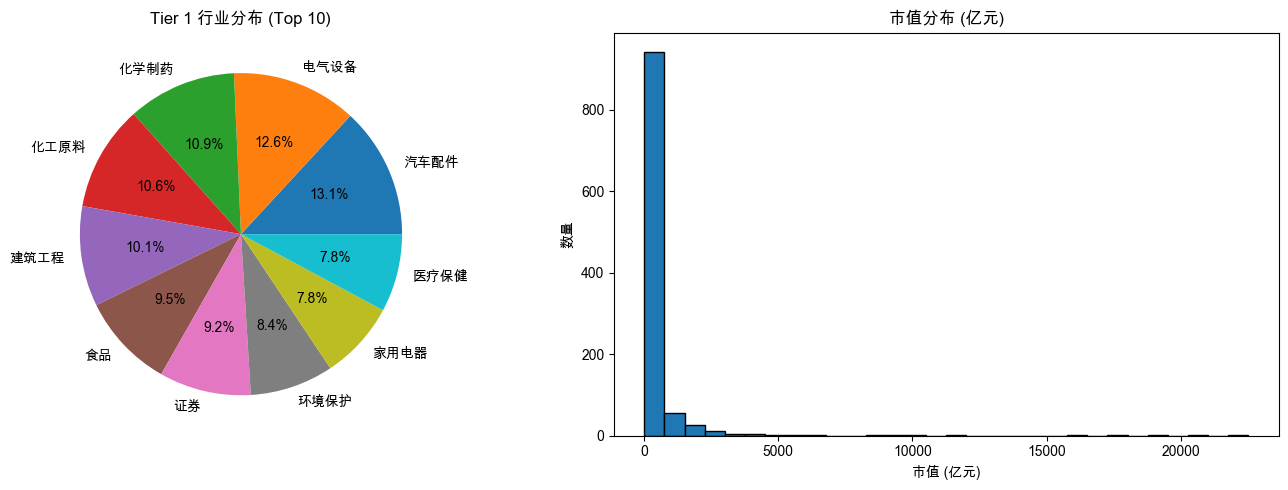

In [3]:
# Cell 2: Tier 1 批量粗筛
bulk_df = screener._tier1_bulk_data()
print(f'全A股数量: {len(bulk_df)}')

filtered = screener._tier1_filter(bulk_df)

if filtered.empty:
    main = obs = filtered
    print('\nTier 1 筛选结果: 无股票通过筛选')
else:
    main = filtered[filtered['channel'] == 'main']
    obs = filtered[filtered['channel'] == 'observation']
    print(f'\nTier 1 筛选结果:')
    print(f'  通过筛选: {len(filtered)} 只')
    print(f'  主通道: {len(main)} 只 (PE > 0 且 <= {config.max_pe})')
    print(f'  观察通道: {len(obs)} 只 (PE = NaN, 亏损股, 按市值取前{config.obs_channel_limit})')

# 行业分布饼图
if not filtered.empty and 'industry' in filtered.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 行业分布
    top_industries = filtered['industry'].value_counts().head(10)
    top_industries.plot.pie(ax=axes[0], autopct='%1.1f%%')
    axes[0].set_title('Tier 1 行业分布 (Top 10)')
    axes[0].set_ylabel('')
    
    # 市值分布
    (filtered['total_mv'] / 10000).plot.hist(ax=axes[1], bins=30, edgecolor='black')
    axes[1].set_title('市值分布 (亿元)')
    axes[1].set_xlabel('市值 (亿元)')
    axes[1].set_ylabel('数量')
    
    plt.tight_layout()
    plt.show()

## Step 3: Tier 1 排序与截断

通过粗筛的股票按**综合得分**排序，取 Top 200 进入 Tier 2。

### 排序公式

```
Tier1 Score = 0.4 × dv_norm + 0.3 × (1/PE)_norm + 0.3 × (1/PB)_norm
```

- **`dv_norm`**：股息率归一化（min-max scaling 到 0~1）
- **`(1/PE)_norm`**：市盈率倒数归一化（PE越低得分越高）
- **`(1/PB)_norm`**：市净率倒数归一化（PB越低得分越高）

### 权重设计理念

| 因子 | 权重 | 理由 |
|------|------|------|
| 股息率 | **40%** | 龟龟策略以收息为核心，股息率是最直接的回报指标 |
| 1/PE | 30% | 低PE意味着更快的盈利回本速度 |
| 1/PB | 30% | 低PB提供资产安全垫，降低永久性亏损风险 |

### 截断规则

- **主通道**：取 Top 150（`tier2_main_limit`）
- **观察通道**：取 Top 50（`obs_channel_limit`）
- 合计 ~200 只进入 Tier 2 逐股深度分析

进入 Tier 2: 200 只 (主通道 150, 观察通道 50)


,ts_code,name,industry,close,pe_ttm,pb,dv_ttm,turnover_rate,tier1_score,channel
0,601186.SH,中国铁建,建筑工程,7.270000,4.6,0.36,4.13,0.67,0.702,main
1,601668.SH,中国建筑,建筑工程,5.050000,4.7,0.43,5.38,0.70,0.690,main
2,601919.SH,中远海控,水运,15.790000,6.4,1.09,10.11,1.19,0.620,main
3,000498.SZ,山东路桥,建筑工程,6.120000,4.2,0.60,3.33,0.89,0.587,main
4,601390.SH,中国中铁,建筑工程,5.930000,5.9,0.47,4.39,1.27,0.585,main
5,601800.SH,中国交建,建筑工程,8.110000,6.4,0.45,3.44,0.33,0.547,main
6,603508.SH,思维列控,IT设备,26.220000,16.2,2.60,12.54,0.56,0.519,main
7,600502.SH,安徽建工,建筑工程,4.810000,6.9,0.75,6.03,1.40,0.517,main
8,000651.SZ,格力电器,家用电器,37.400000,6.6,1.51,8.00,0.48,0.516,main
9,603565.SH,中谷物流,水运,11.040000,10.8,2.35,11.05,0.68,0.514,main


,ts_code,name,industry,close,pe_ttm,pb,dv_ttm,turnover_rate,tier1_score,channel
150,002379.SZ,宏桥控股,铝,30.510000,—,6.09,—,2.27,0.000,observation
151,002460.SZ,赣锋锂业,小金属,65.890000,—,3.32,0.23,2.85,0.000,observation
152,601012.SH,隆基绿能,电气设备,18.000000,—,2.40,—,1.59,0.000,observation
153,600029.SH,南方航空,空运,6.630000,—,3.24,—,0.66,0.000,observation
154,600115.SH,中国东航,空运,5.120000,—,7.05,—,1.15,0.000,observation
155,002466.SZ,天齐锂业,小金属,51.990000,—,1.98,—,1.73,0.000,observation
156,000301.SZ,东方盛虹,化纤,12.930000,—,2.56,—,0.60,0.000,observation
157,601360.SH,三六零,互联网,11.530000,—,2.75,1.73,1.14,0.000,observation
158,601238.SH,广汽集团,汽车整车,7.830000,—,0.72,0.25,0.18,0.000,observation
159,688223.SH,晶科能源,电气设备,7.340000,—,2.69,—,2.16,0.000,observation


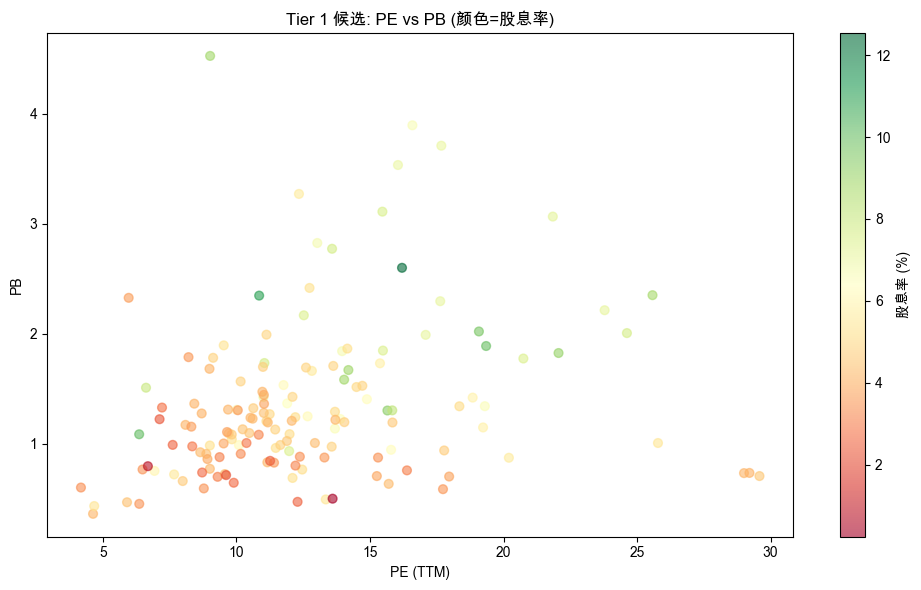

In [4]:
# Cell 3: Tier 1 排序与截断
ranked = screener._tier1_rank_and_cut(filtered)
main_ranked = ranked[ranked['channel'] == 'main']
obs_ranked = ranked[ranked['channel'] == 'observation']
print(f'进入 Tier 2: {len(ranked)} 只 (主通道 {len(main_ranked)}, 观察通道 {len(obs_ranked)})')

# 展示主通道候选列表
display_cols = ['ts_code', 'name', 'industry', 'close', 'pe_ttm', 'pb',
                'dv_ttm', 'turnover_rate', 'tier1_score', 'channel']
display_cols = [c for c in display_cols if c in ranked.columns]
display(main_ranked[display_cols].head(20).style
        .format({'pe_ttm': '{:.1f}', 'pb': '{:.2f}', 'dv_ttm': '{:.2f}',
                 'tier1_score': '{:.3f}', 'turnover_rate': '{:.2f}'},
                na_rep='—')
        .set_caption(f'主通道 Top 20 / {len(main_ranked)}'))

# 展示观察通道（亏损股）
if not obs_ranked.empty:
    display(obs_ranked[display_cols].head(20).style
            .format({'pe_ttm': '{:.1f}', 'pb': '{:.2f}', 'dv_ttm': '{:.2f}',
                     'tier1_score': '{:.3f}', 'turnover_rate': '{:.2f}'},
                    na_rep='—')
            .set_caption(f'观察通道 Top 20 / {len(obs_ranked)}'))

# PE/PB/股息率 散点图
if not ranked.empty:
    main_r = ranked[ranked['channel'] == 'main']
    if not main_r.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        scatter = ax.scatter(main_r['pe_ttm'], main_r['pb'],
                           c=main_r['dv_ttm'], cmap='RdYlGn',
                           s=40, alpha=0.6)
        plt.colorbar(scatter, label='股息率 (%)')
        ax.set_xlabel('PE (TTM)')
        ax.set_ylabel('PB')
        ax.set_title('Tier 1 候选: PE vs PB (颜色=股息率)')
        plt.tight_layout()
        plt.show()


## Step 4: Tier 2 逐股深度分析

对 Tier 1 候选的每只股票，逐一拉取完整财务数据并进行多维度评估。

### 分析流水线（每只股票）

**第一关：硬性否决（一票否决制）**
- 质押比例 > 70% → **直接拒绝**（大股东质押过高，存在爆仓风险）
- 非标审计意见 → **直接拒绝**（财务数据可信度存疑）

**第二关：质量门槛**
- ROE(加权) ≥ 8% — 资本回报效率须高于无风险收益率
- 毛利率 ≥ 15% — 须具备基本的定价权和护城河
- 资产负债率 ≤ 70% — 财务杠杆不可过高

**第三关：因子计算**

| 因子 | 公式 | 含义 |
|------|------|------|
| **因子2 穿透回报率R** | `R = AA × M / 市值` | AA=真实可支配现金结余, M=支付率。衡量"公司真实现金流中能分给你多少" |
| **因子4a EV/EBITDA** | `(市值+净负债) / EBITDA` | 企业价值倍数，越低越便宜 |
| **因子4b FCF收益率** | `自由现金流 / 市值` | 现金创造能力，越高越好 |
| **因子4c 商誉比** | `商誉 / 总资产` | 并购风险，越低越安全 |

**第四关：底价计算**
- 5种方法取中位数：净资产法、股息贴现法、清算价值法等
- `底价溢价率 = (现价 - 底价) / 底价`，负值表示现价低于底价（有安全边际）

> **TIER2_LIMIT 参数**：控制分析数量。设为 `5` 可快速测试，`None` 则分析全部 ~200 只。

In [6]:
# Cell 4: Tier 2 逐股深度分析
# 可调整 tier2_limit 控制分析数量 (None = 全部, 5 = 快速测试)
TIER2_LIMIT = 50 # 修改此值: None=全部200只, 5=快速测试

try:
    from tqdm.notebook import tqdm
    pbar = tqdm(total=min(TIER2_LIMIT or len(ranked), len(ranked)),
                desc='Tier 2 分析')
    def _progress(current, total, ts_code):
        pbar.n = current
        pbar.total = total
        pbar.set_postfix(stock=ts_code)
        pbar.refresh()
    
    result = screener.run(tier2_limit=TIER2_LIMIT, progress_callback=_progress)
    pbar.close()
except ImportError:
    result = screener.run(tier2_limit=TIER2_LIMIT)

print(f'\nTier 2 通过: {len(result)} 只')

Tier 2 分析:   0%|          | 0/50 [00:00<?, ?it/s]

=== Tier 1: Bulk screening ===
  stock_basic: 5489 rows
  daily_basic: 5477 rows
  Universe: 5477 stocks
  After filters: 1060 stocks (main: 1010, observation: 50)
  After rank & cut: 200 stocks

=== Tier 2: Deep analysis (50 stocks) ===
 VETOED
 VETOED
 OK
 VETOED
 VETOED
 VETOED
 OK
 VETOED
 OK
 OK
 VETOED
 VETOED
 VETOED
 OK
 OK
 OK
 OK
 OK
 OK
 OK
 VETOED
 VETOED
 VETOED
 VETOED
 VETOED
 OK
 OK
 OK
 OK
 VETOED
 VETOED
 VETOED
 OK
 VETOED
 VETOED
 VETOED
 VETOED
 OK
 VETOED
 OK
 OK
 OK
 VETOED
 VETOED
 VETOED
 OK
 OK
 OK
 VETOED
 VETOED

=== Results: 23 stocks passed ===

Tier 2 通过: 23 只


## Step 5: 综合评分与排名

Tier 2 通过的股票按 **5个维度** 加权计算综合得分，采用**百分位排名法**（percentile ranking）。

### 评分公式

```
Composite Score = 0.20×ROE_pct + 0.20×FCF_pct + 0.25×R_pct + 0.15×EV_pct + 0.20×Floor_pct
```

| 维度 | 权重 | 指标 | 方向 | 理由 |
|------|------|------|------|------|
| ROE | 20% | ROE(加权) | 越高越好 | 资本回报效率 |
| FCF收益率 | 20% | FCF/市值 | 越高越好 | 现金创造能力 |
| **穿透回报率R** | **25%** | C×M/市值 | 越高越好 | 分红可持续性，策略核心指标 |
| EV/EBITDA | 15% | 企业价值倍数 | 越低越好 | 估值便宜程度 |
| 底价溢价率 | 20% | (现价-底价)/底价 | 越低越好 | 安全边际 |

> **为什么穿透回报率R权重最高（25%）？**
> R 综合了分红比例和盈利能力，直接回答"持有这只股票，每年能拿到多少真金白银"。
> 这是龟龟策略区别于普通价值投资的核心——不仅要便宜，还要能持续产生现金回报。

### 排名方法
每个指标在全样本中的百分位即为该维度得分（0~1），加权求和后按 Composite Score 降序排列。

,ts_code,name,industry,close,pe_ttm,pb,dv_ttm,roe_waa,gross_margin,fcf_yield,R,ev_ebitda,floor_premium,composite_score
0,601919.SH,中远海控,水运,15.790000,6.4,1.09,10.11,22.6%,29.5%,17.91%,4.82%,1.3x,3.0%,0.722
14,600582.SH,天地科技,专用机械,6.060000,9.0,0.98,5.23,11.1%,30.5%,17.58%,—,2.5x,2.7%,0.713
2,000651.SZ,格力电器,家用电器,37.400000,6.6,1.51,8.00,25.4%,29.4%,12.44%,—,4.0x,114.8%,0.641
12,600729.SH,重庆百货,百货,23.200000,10.0,1.31,6.56,18.6%,26.5%,18.35%,—,3.8x,372.6%,0.637
11,002572.SZ,索菲亚,家居用品,12.970000,11.0,1.73,7.71,19.3%,35.4%,5.94%,—,5.8x,28.0%,0.607
22,600566.SH,济川药业,中成药,27.750000,15.5,1.85,7.52,18.2%,79.2%,7.83%,—,6.2x,73.9%,0.593
13,600035.SH,楚天高速,路桥,4.000000,9.6,0.72,4.25,9.2%,32.2%,14.41%,—,6.8x,5.9%,0.587
9,605368.SH,蓝天燃气,供气供热,8.500000,19.3,1.89,10.00,13.6%,19.4%,6.55%,—,7.2x,10.1%,0.583
18,002035.SZ,华帝股份,家用电器,6.130000,11.9,1.37,6.40,13.3%,40.7%,7.59%,—,5.5x,74.4%,0.567
17,002867.SZ,周大生,服饰,11.960000,12.5,2.17,7.53,15.7%,20.8%,12.79%,—,8.9x,68.6%,0.559


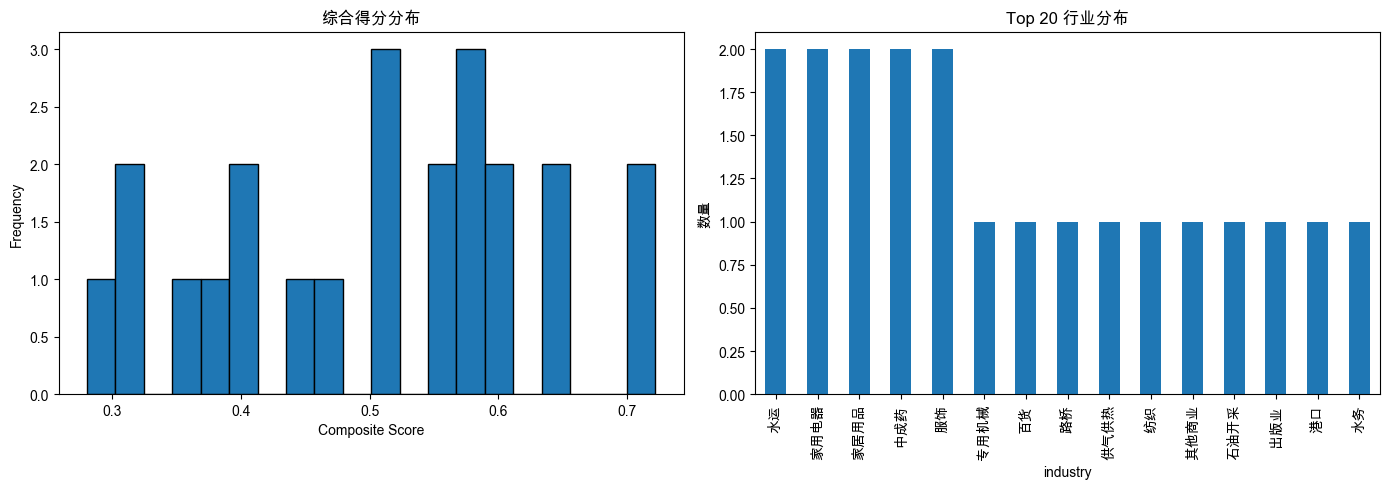

In [7]:
# Cell 5: 综合评分与排名
if not result.empty:
    display_cols = ['ts_code', 'name', 'industry', 'close', 'pe_ttm', 'pb',
                    'dv_ttm', 'roe_waa', 'gross_margin', 'fcf_yield', 'R',
                    'ev_ebitda', 'floor_premium', 'composite_score']
    display_cols = [c for c in display_cols if c in result.columns]
    
    top50 = result[display_cols].head(50)
    
    styled = (top50.style
        .format({
            'pe_ttm': '{:.1f}', 'pb': '{:.2f}', 'dv_ttm': '{:.2f}',
            'roe_waa': '{:.1f}%', 'gross_margin': '{:.1f}%',
            'fcf_yield': '{:.2f}%', 'R': '{:.2f}%',
            'ev_ebitda': '{:.1f}x', 'floor_premium': '{:.1f}%',
            'composite_score': '{:.3f}'
        }, na_rep='—')
        .background_gradient(subset=['composite_score'], cmap='RdYlGn')
        .set_caption(f'综合排名 Top {len(top50)}'))
    display(styled)
    
    # 综合得分分布
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    result['composite_score'].plot.hist(ax=axes[0], bins=20, edgecolor='black')
    axes[0].set_title('综合得分分布')
    axes[0].set_xlabel('Composite Score')
    
    # Top 10 行业分布
    if 'industry' in result.columns:
        result.head(20)['industry'].value_counts().plot.bar(ax=axes[1])
        axes[1].set_title('Top 20 行业分布')
        axes[1].set_ylabel('数量')
    
    plt.tight_layout()
    plt.show()
else:
    print('无结果')

## Step 6: 结果导出

将筛选结果导出为三种格式：
- **CSV** — 适合后续程序处理或导入 Excel
- **HTML** — 带格式的网页表格，可直接在浏览器中查看
- **Excel** — 完整工作簿（需安装 `openpyxl`）

所有文件输出到 `output/` 目录。

In [ ]:
# Cell 6: 结果导出
if not result.empty:
    os.makedirs('../output', exist_ok=True)
    
    # CSV
    csv_path = '../output/screener_results.csv'
    screener.export_csv(result, csv_path)
    
    # HTML
    html_path = '../output/screener_results.html'
    screener.export_html(result, html_path)
    
    # Excel (optional)
    try:
        xlsx_path = '../output/screener_results.xlsx'
        result.to_excel(xlsx_path, index=False)
        print(f'Excel: {xlsx_path}')
    except Exception as e:
        print(f'Excel export skipped: {e}')
    
    print(f'\n共导出 {len(result)} 只股票')
else:
    print('无数据可导出')

## Step 7: 单股深入查看

输入任意股票代码，查看该股的所有指标详情及其在全样本中的**百分位位置**。

百分位解读：
- **百分位 90%** = 该指标优于90%的候选股（非常好）
- **百分位 50%** = 中位数水平
- **百分位 10%** = 该指标仅优于10%的候选股（较差）

> 修改 `STOCK_CODE` 变量即可切换查看不同股票。

In [ ]:
# Cell 7 (可选): 单股深入查看
# 输入股票代码，查看该股详细指标及在全样本中的百分位位置

STOCK_CODE = '600887.SH'  # 修改此处查看不同股票

if not result.empty and STOCK_CODE in result['ts_code'].values:
    stock = result[result['ts_code'] == STOCK_CODE].iloc[0]
    
    print(f"=== {stock['name']} ({STOCK_CODE}) ===")
    print(f"当前价格: {stock.get('close', '—')}")
    print(f"综合得分: {stock.get('composite_score', '—'):.3f}")
    rank = (result['ts_code'] == STOCK_CODE).values.argmax() + 1
    print(f"排名: {rank}/{len(result)}")
    print()
    
    metrics = [
        ('ROE(加权)', 'roe_waa', '%'),
        ('毛利率', 'gross_margin', '%'),
        ('FCF收益率', 'fcf_yield', '%'),
        ('穿透回报率R', 'R', '%'),
        ('EV/EBITDA', 'ev_ebitda', 'x'),
        ('底价溢价率', 'floor_premium', '%'),
        ('商誉/总资产', 'goodwill_ratio', '%'),
        ('净负债/EBITDA', 'net_debt_ebitda', 'x'),
    ]
    
    for label, col, unit in metrics:
        val = stock.get(col)
        if val is not None and val == val:
            pctile = (result[col] <= val).mean() * 100 if col in result.columns else None
            pctile_str = f" (百分位: {pctile:.0f}%)" if pctile is not None else ''
            print(f"  {label}: {val:.2f}{unit}{pctile_str}")
        else:
            print(f"  {label}: —")
else:
    if result.empty:
        print('请先运行 Cell 4-5')
    else:
        print(f'{STOCK_CODE} 不在结果中。可用股票:')
        print(result['ts_code'].head(10).tolist())